# Comparison to metabolomics 
Comparison to https://doi.org/10.1158/1078-0432.CCR-13-1939


In [34]:
import os
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
from plotnine import *

## Metabolomics data input

In [35]:
vip_df = pd.DataFrame({
    'VIP_Score_Hangzhou': [2.22, 1.54, 1.33, 2.10],
    'VIP_Score_Hope': [1.86, 1.83, 1.7, 1.63],
    'VIP_Score_Beijing': [1.72, 1.27, 1.17, 1.8]
}, index=['Glutamate', 'Palmitoleate', 'Aspartate', 'Lactate'])

## Proteomics data input

In [36]:
adata = ad.read_h5ad('../../data/adata_consensus_cell_types.h5ad')

In [37]:
related_metab_markers = ['LDH', 'MCT1', 'GS', 'GLS', 'CPT1A', 'CS', 'ASCT2']

In [38]:
# Add tumor stage
clini = pd.read_csv("../../data/summary_clinical_data_modified.csv", index_col=2)
adata.obs = adata.obs.merge(clini, left_on="fov", right_index=True, how="left")

In [39]:
adata.obs["Stage"] = adata.obs["pT group"]
# # E1 and E2 samples are annotated 'SCT' while E3 and E4 are 'Colon-no.'
adata.obs.loc[adata.obs.fov.str.contains("E4"), "Stage"] = "Colon-no."
adata.obs.loc[adata.obs.fov.str.contains("E3"), "Stage"] = "Colon-no."
adata.obs.loc[adata.obs.fov.str.contains("E2"), "Stage"] = "SCT"
adata.obs.loc[adata.obs.fov.str.contains("E1"), "Stage"] = "SCT"

In [40]:
df = adata.obs.loc[:,related_metab_markers+["fov"]]
df["cell_type"] = adata.obs["annotation_consensus"].values

* ~~Plot metabolite VIP scores as line plot (plotnine, each metabolite in a separate plot)~~
* ~~Drop FOVs with less than <50% epithelial cells, then merge per FOV.~~
* ~~Add field for healthy versus cancer samples~~
* ~~Represent boxplots of each marker in healthy versus cancer (plotnine, each marker in a separate plot)~~
* ~~Compute the fold-change between median in healthy versus cancer~~
* ~~Scatter plot: median VIP score per metabolite against FC of the corresponding regulators (one point per regulator). Annotate each regulator on the plot. Associations are:~~
    * ~~'LDH' with lactate~~
    * ~~'MCT1' with lactate~~
    * ~~'GS' with glutamate~~
    * ~~'GLS' with glutamate~~
    * ~~'CPT1A' with palmitoleate~~
    * ~~'CS' with aspartate~~


/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 1.7 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_vip_Glutamate.pdf
/tmp/ipykernel_841074/3435141068.py:21: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


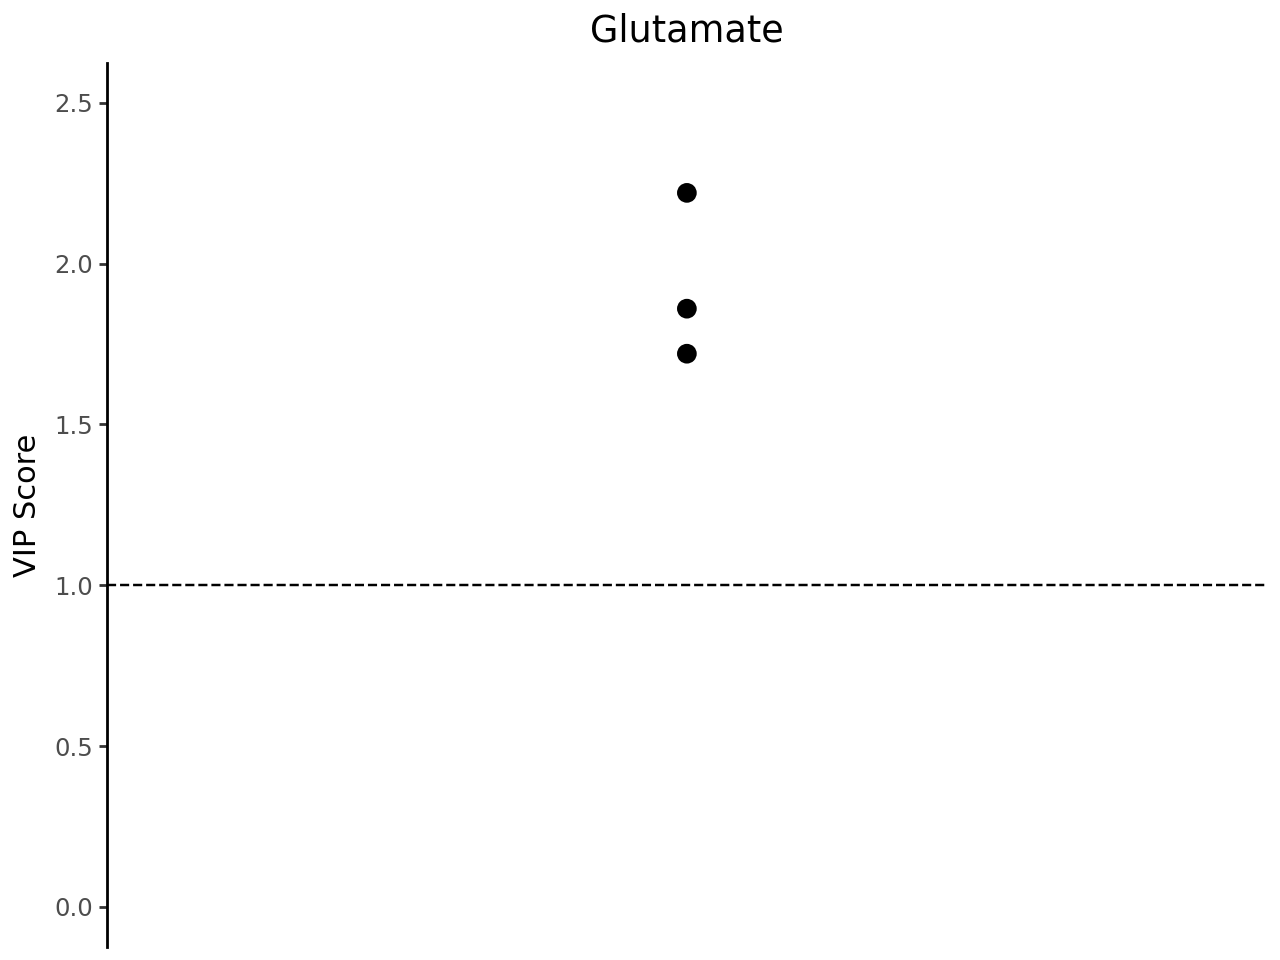

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 1.7 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_vip_Palmitoleate.pdf
/tmp/ipykernel_841074/3435141068.py:21: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


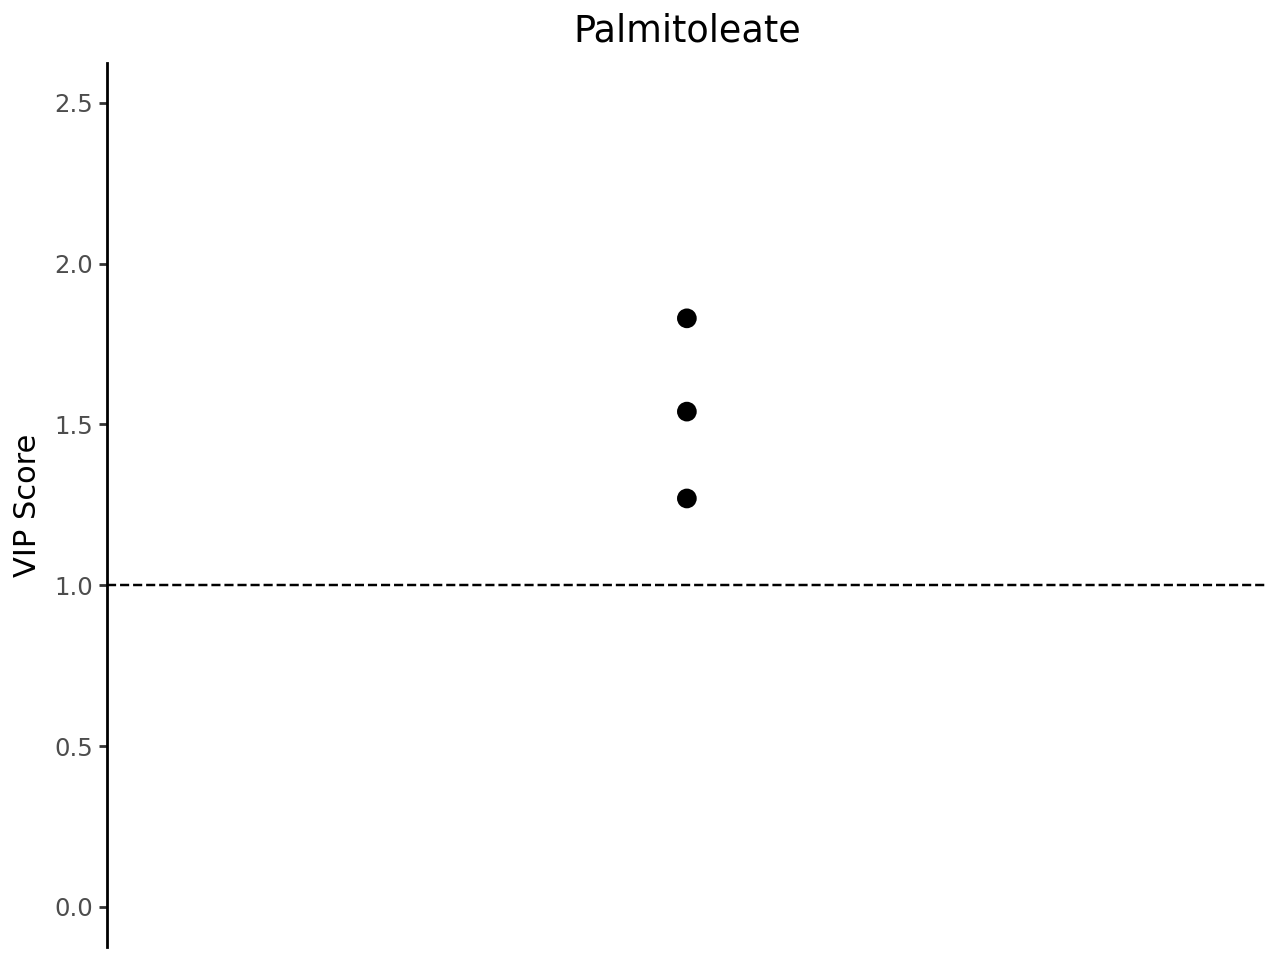

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 1.7 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_vip_Aspartate.pdf
/tmp/ipykernel_841074/3435141068.py:21: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


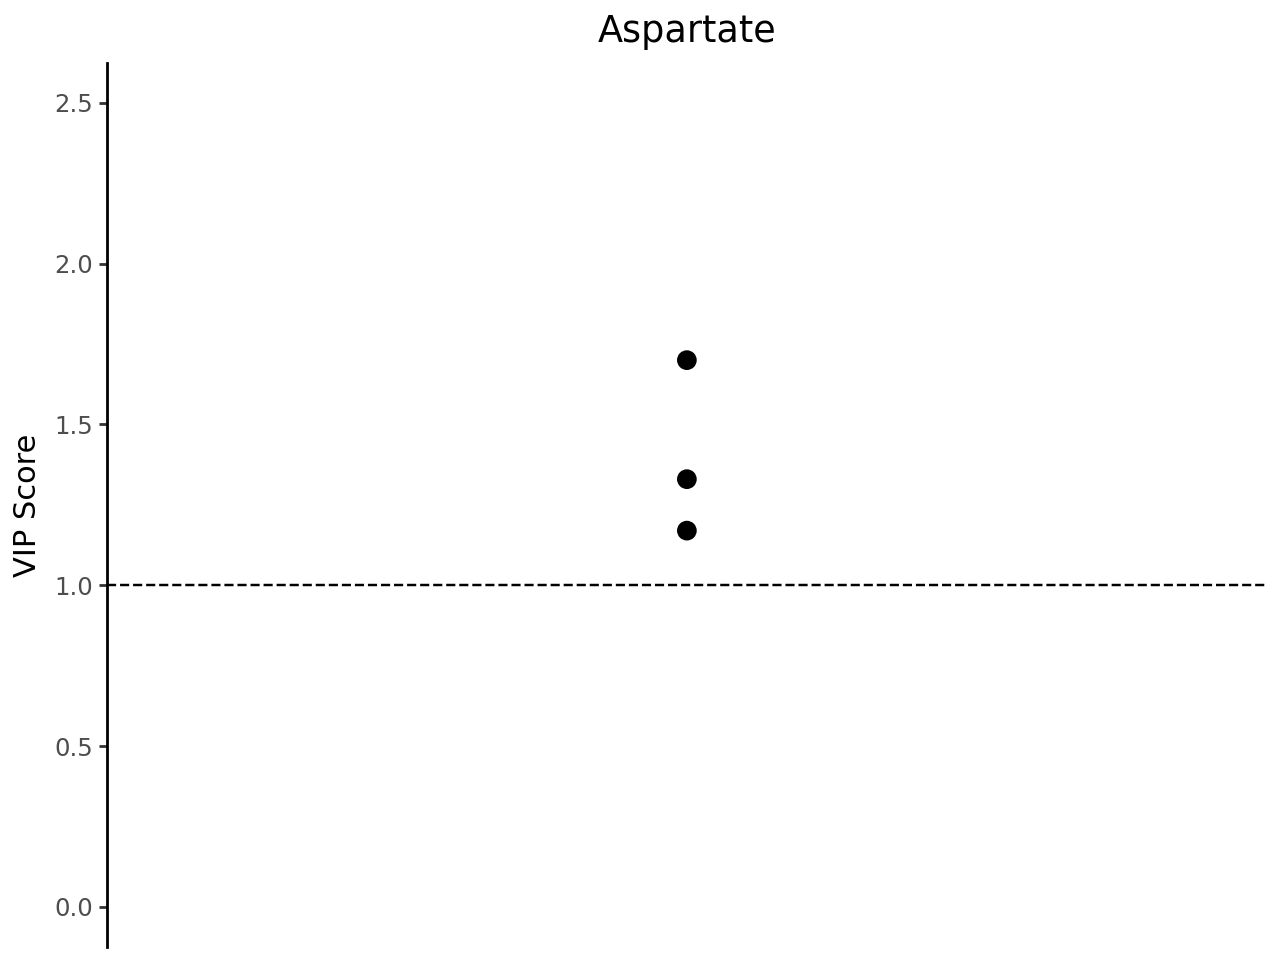

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 1.7 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_vip_Lactate.pdf
/tmp/ipykernel_841074/3435141068.py:21: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


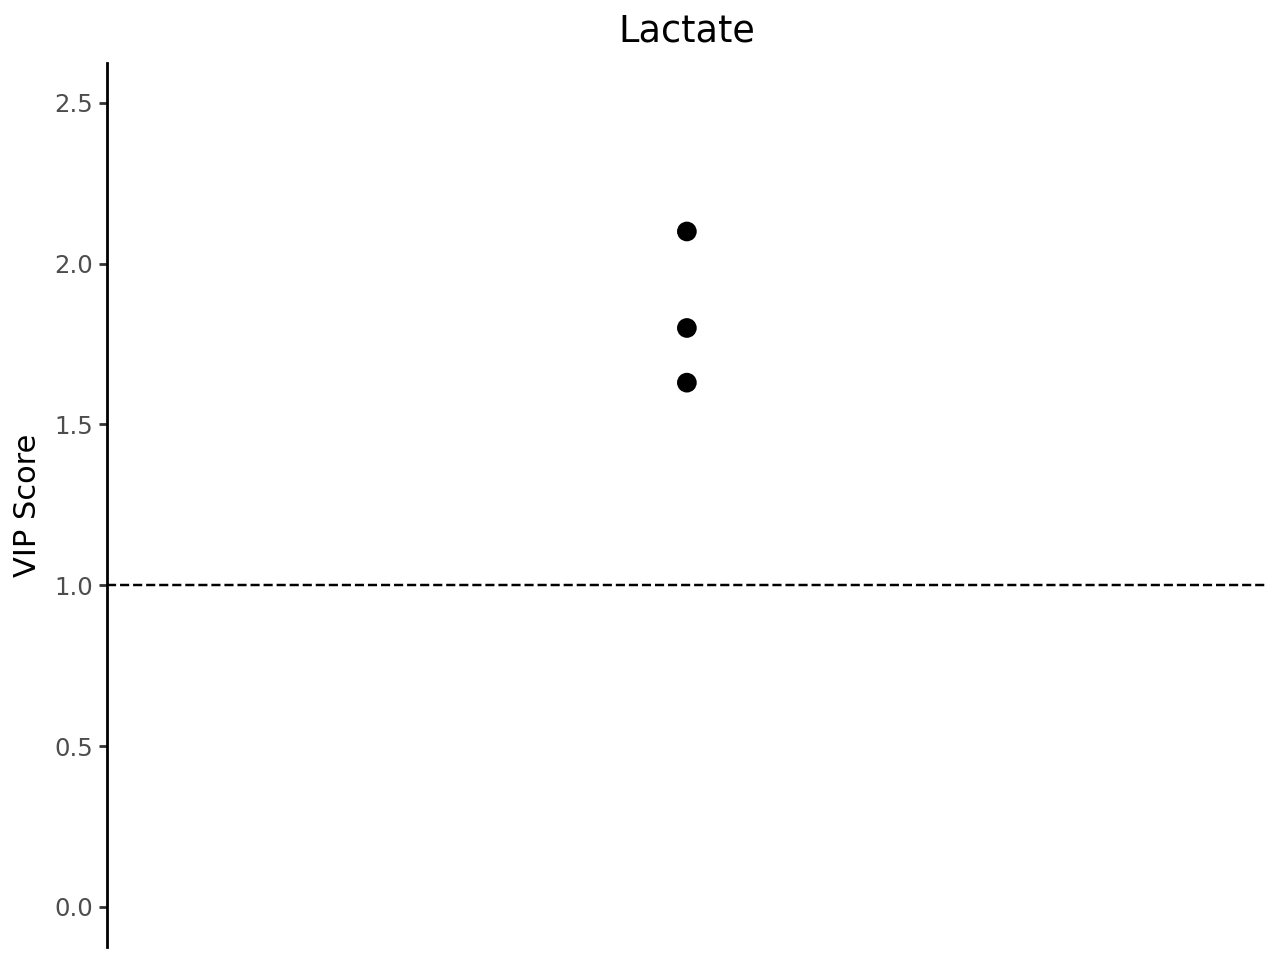

In [41]:
# 1D dot plot of VIP scores per metabolite
vip_long = (vip_df.reset_index()
            .melt(id_vars='index', var_name='Cohort', value_name='VIP_Score')
            .rename(columns={'index': 'Metabolite'}))

for metabolite in vip_long['Metabolite'].unique():
    sub = vip_long[vip_long['Metabolite'] == metabolite].copy()
    sub['y'] = 0
    p = (ggplot(sub, aes(x='VIP_Score', y='y'))
         + coord_flip()
         + geom_point(size=3)
         + geom_vline(xintercept=1, linetype='dashed')
         + xlim(0, 2.5)
         + labs(title=metabolite, x='VIP Score', y='')
         + theme_classic()
         + theme(axis_text_x=element_blank(), axis_ticks_x=element_blank(),
                 axis_line_x=element_blank())
    )

    ggsave(p, filename=f'../../figures/fig3/metabolomics_vip_{metabolite}.pdf', width=1.7, height=4)
    print(p)


In [42]:
# Add Stage to df
df["Stage"] = adata.obs["Stage"].values

# Drop FOVs with less than 30% Cancer_cell
total_per_fov = df.groupby('fov')['cell_type'].count()
epi_per_fov = df[df['cell_type'] == 'Cancer_cell'].groupby('fov')['cell_type'].count()
epi_fraction = (epi_per_fov / total_per_fov).fillna(0)
valid_fovs = epi_fraction[epi_fraction >= 0.3].index

df_filtered = df[df['fov'].isin(valid_fovs)].copy()

# Merge per FOV (mean per FOV)
df_fov = df_filtered.groupby('fov')[related_metab_markers].mean().reset_index()
fov_stage = df_filtered.groupby('fov')['Stage'].first().reset_index()
df_fov = df_fov.merge(fov_stage, on='fov')

# Condition: Healthy (Colon-no.) vs Tumor (not Colon-no., not SCT)
df_fov['Condition'] = df_fov['Stage'].apply(
    lambda s: 'Healthy' if s == 'Colon-no.' else ('Tumor' if s not in ['Colon-no.', 'SCT'] else None)
)
df_fov = df_fov.dropna(subset=['Condition'])
print(df_fov['Condition'].value_counts())


Condition
Tumor      311
Healthy      4
Name: count, dtype: int64


In [43]:
col_pal = ['#7fc97f', '#9e9ac9']

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 2 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_LDH_abundance.pdf
/tmp/ipykernel_841074/2283108078.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


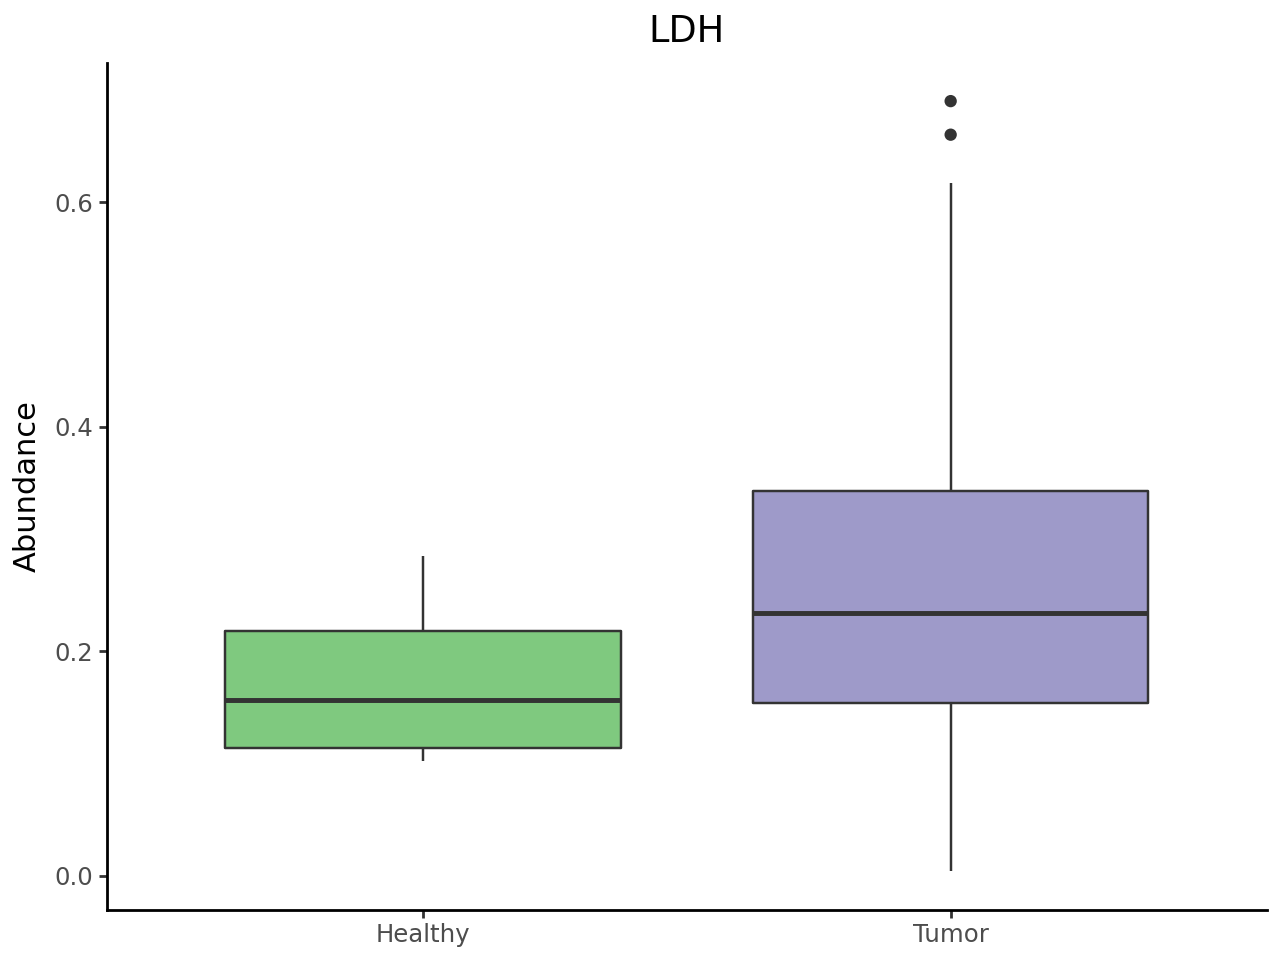

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 2 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_MCT1_abundance.pdf


/tmp/ipykernel_841074/2283108078.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


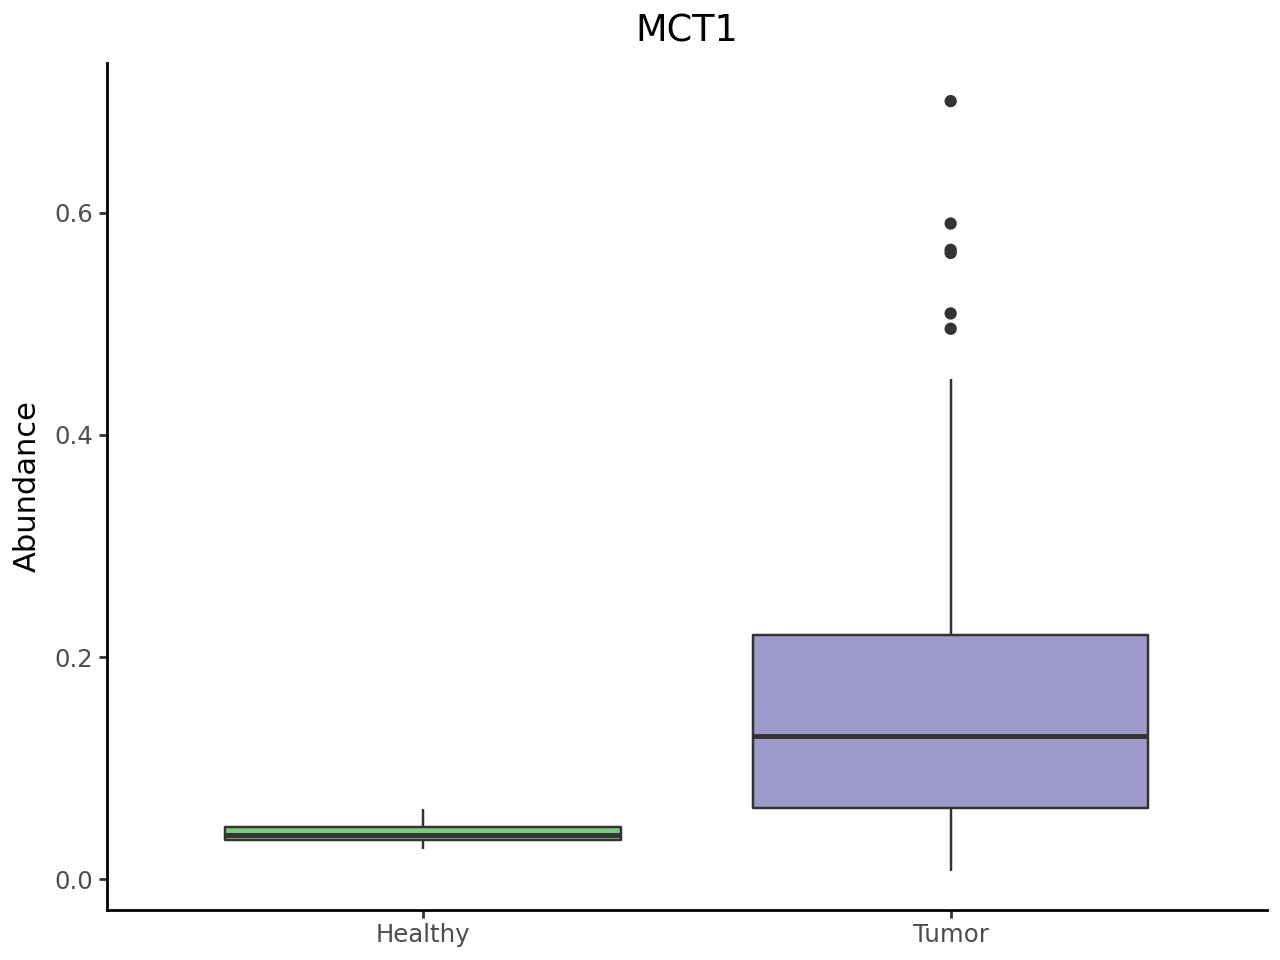

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 2 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_GS_abundance.pdf
/tmp/ipykernel_841074/2283108078.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


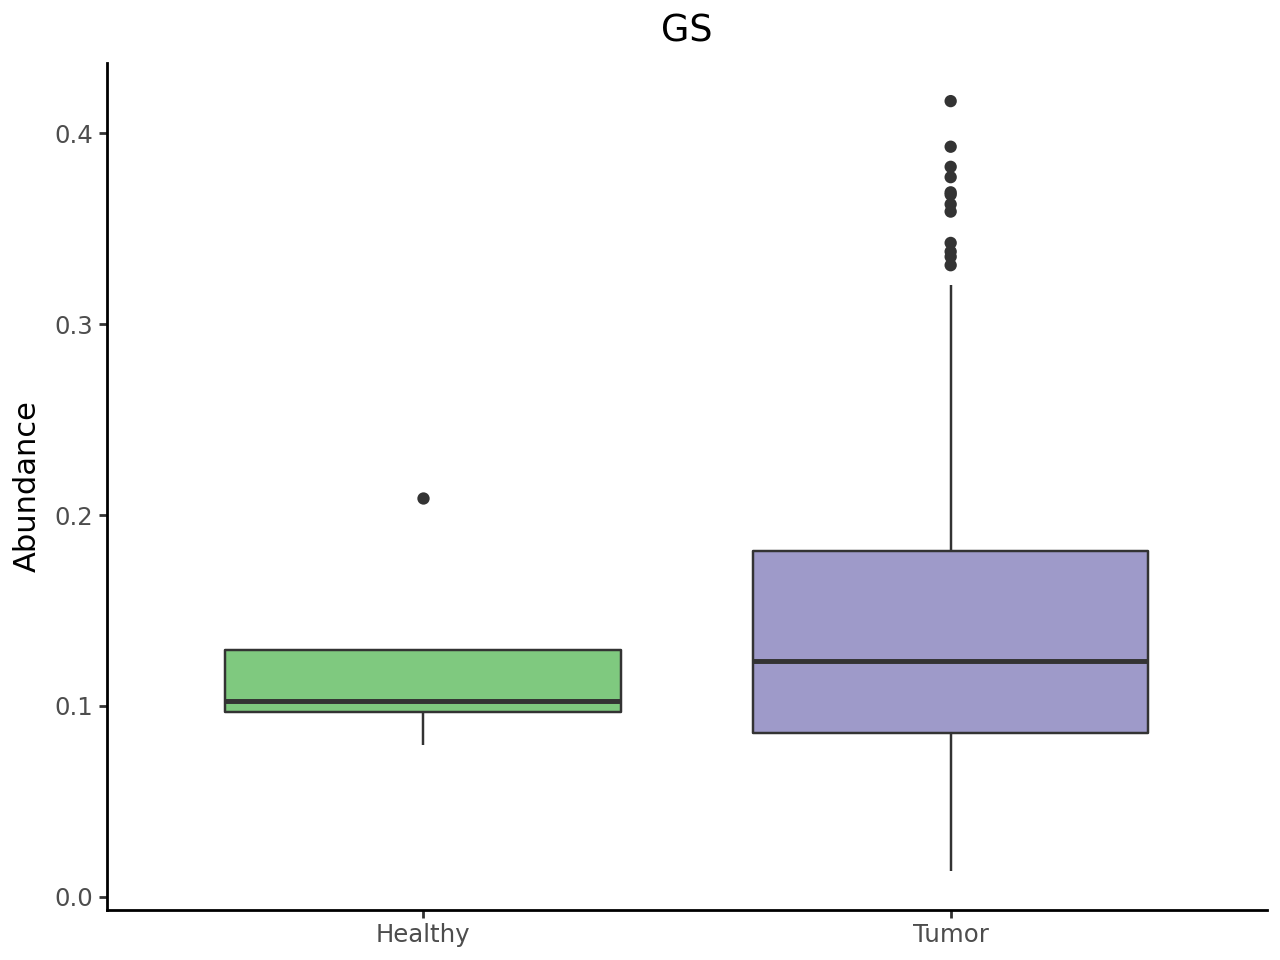

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 2 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_GLS_abundance.pdf
/tmp/ipykernel_841074/2283108078.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


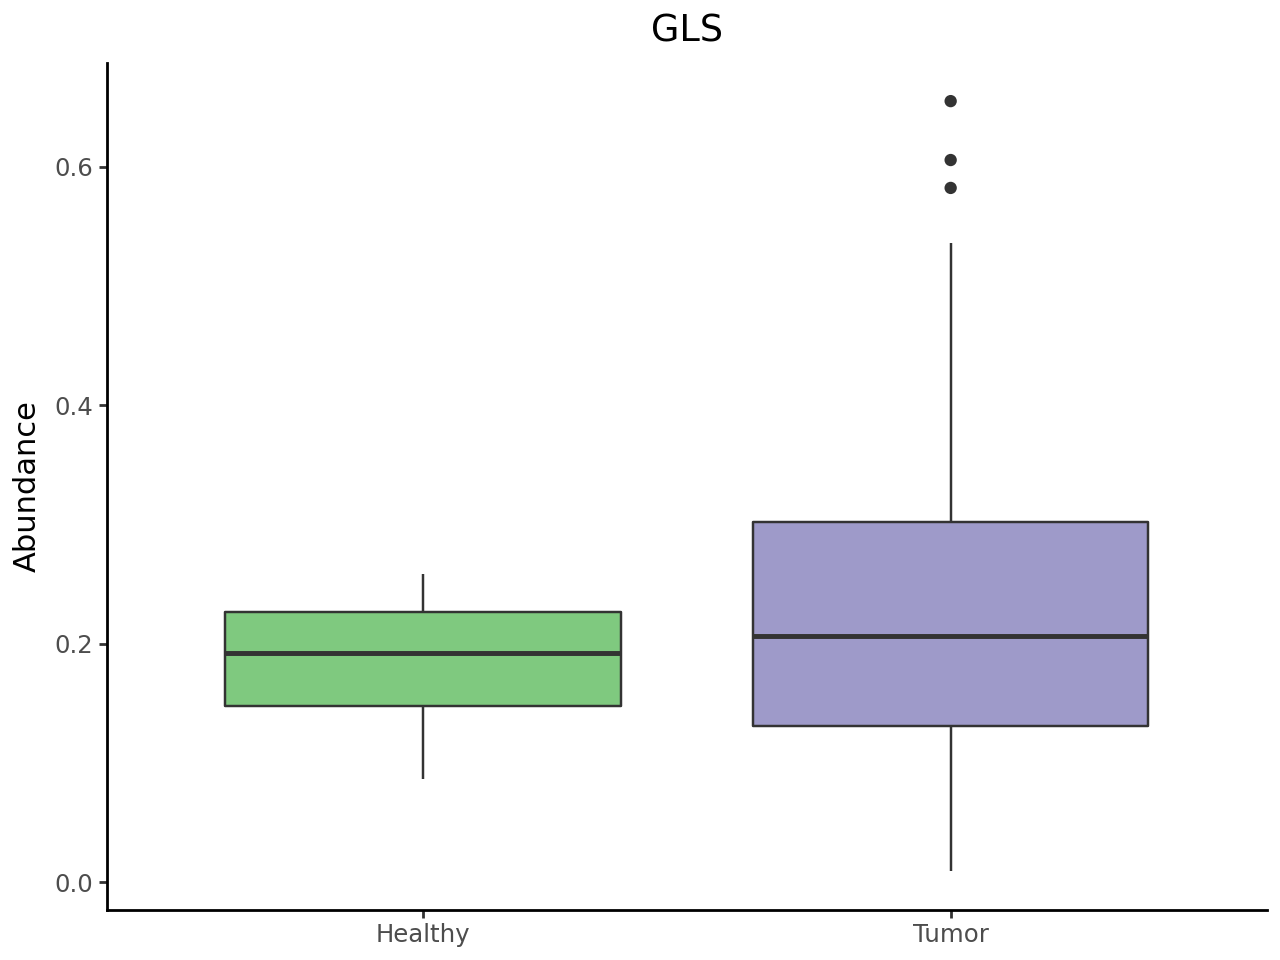

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 2 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_CPT1A_abundance.pdf
/tmp/ipykernel_841074/2283108078.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


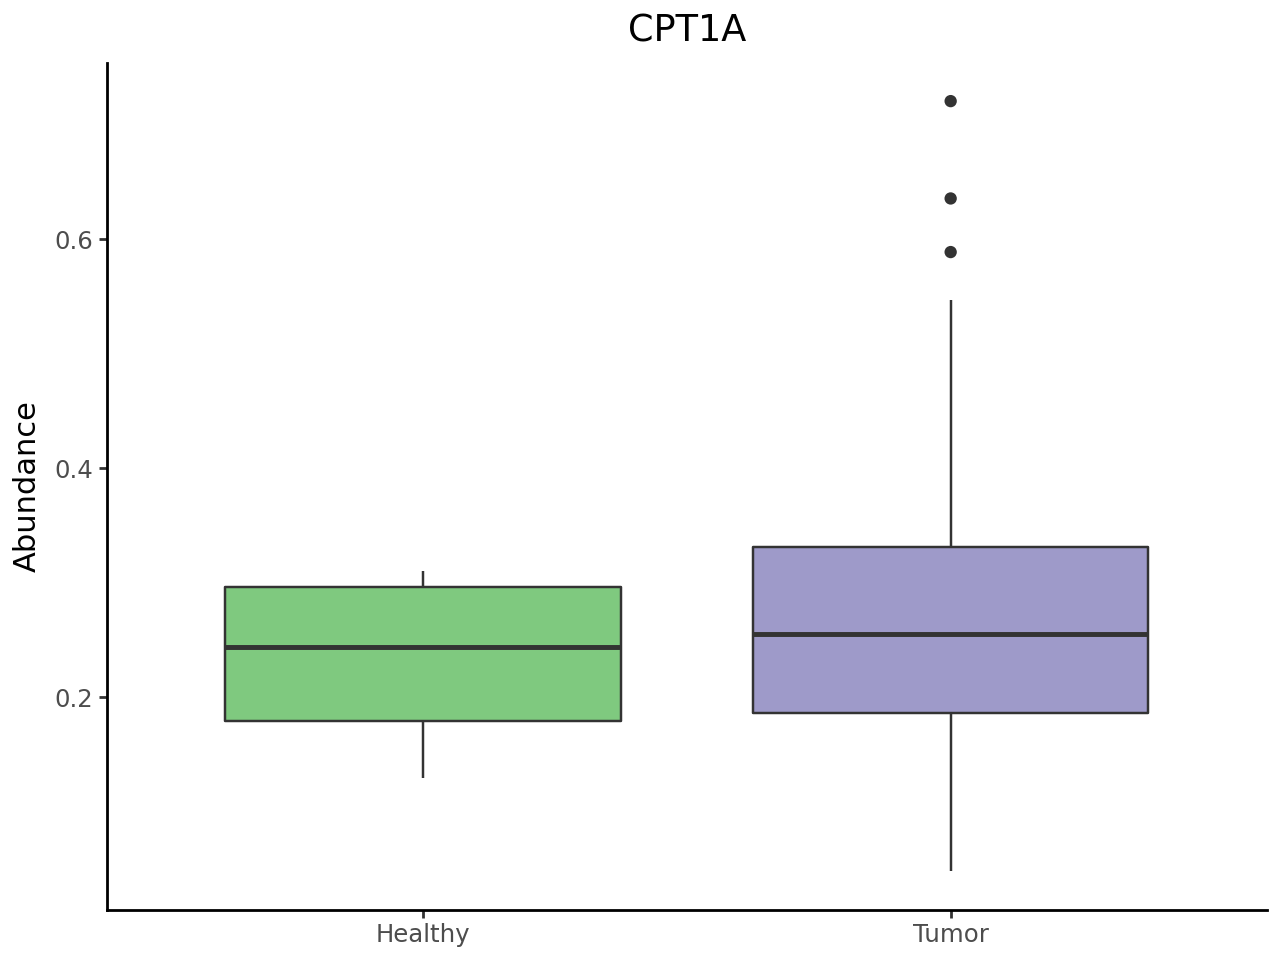

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 2 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_CS_abundance.pdf
/tmp/ipykernel_841074/2283108078.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


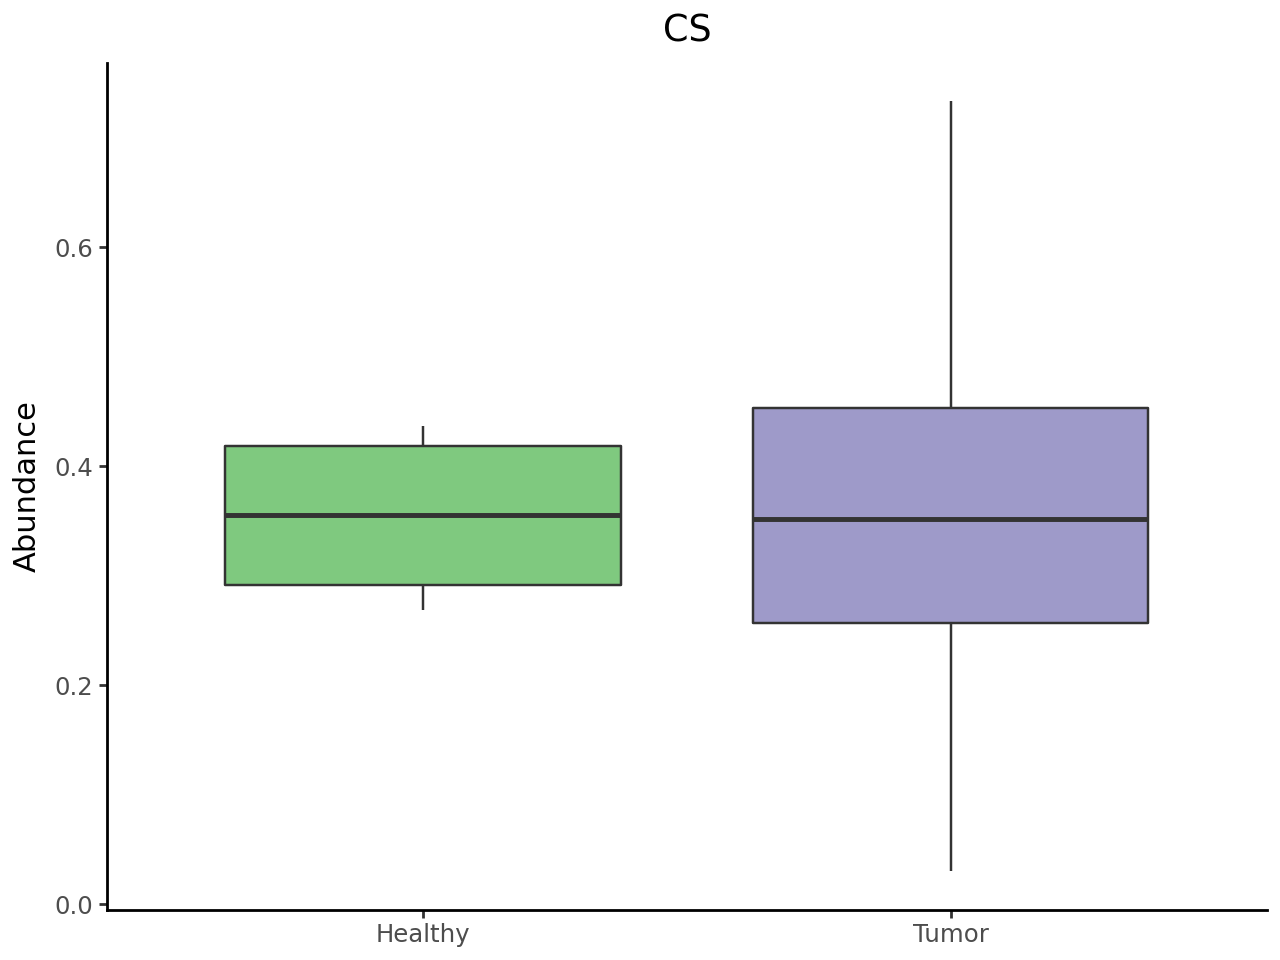

/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 2 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_ASCT2_abundance.pdf


/tmp/ipykernel_841074/2283108078.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


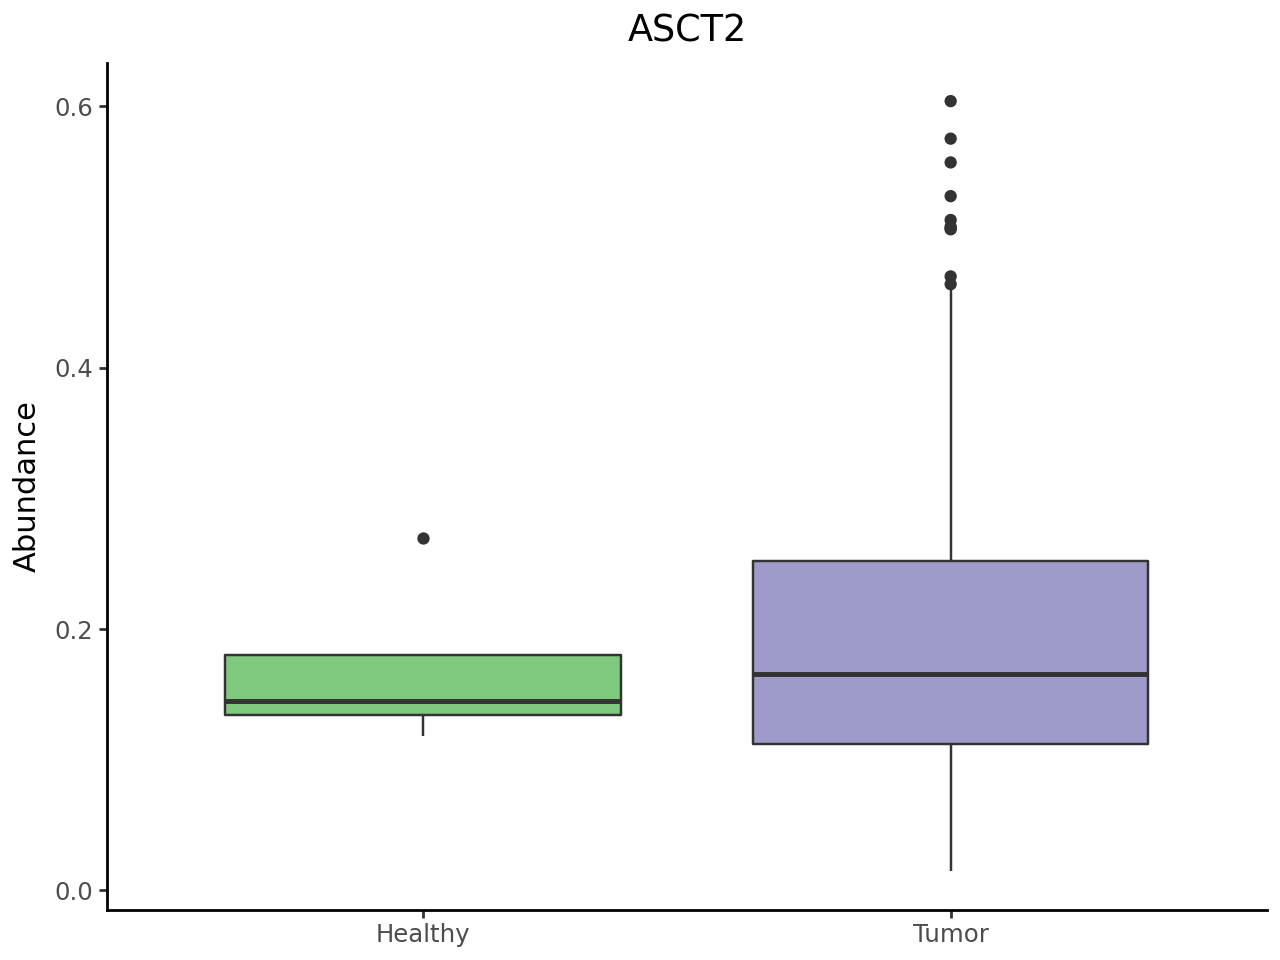

In [44]:
# Boxplots of each marker in healthy vs tumor
df_box = df_fov.melt(
    id_vars=['fov', 'Stage', 'Condition'],
    value_vars=related_metab_markers,
    var_name='Marker', value_name='Abundance'
)

for marker in related_metab_markers:
    sub = df_box[df_box['Marker'] == marker]
    p = (ggplot(sub, aes(x='Condition', y='Abundance', fill='Condition'))
         + geom_boxplot()
         + scale_fill_manual(values=col_pal)
         + labs(title=marker, x='', y='Abundance')
         + theme_classic()
         + theme(legend_position='none'))
    ggsave(p, filename=f'../../figures/fig3/metabolomics_{marker}_abundance.pdf', width=2, height=4)
    print(p)


In [12]:
# Compute fold-change between median in healthy vs cancer
medians = df_fov.groupby('Condition')[related_metab_markers].median()
fc = (medians.loc['Tumor'] / medians.loc['Healthy']).reset_index()
fc.columns = ['Marker', 'FC']
print(fc)


  Marker        FC
0    LDH  1.493101
1   MCT1  3.230121
2     GS  1.202977
3    GLS  1.075577
4  CPT1A  1.045832
5     CS  0.989860


/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 4 x 4 in image.
/home/loan/miniforge3/envs/pam-keras3/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: ../../figures/fig3/metabolomics_scatter.pdf
/tmp/ipykernel_841074/557508150.py:23: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


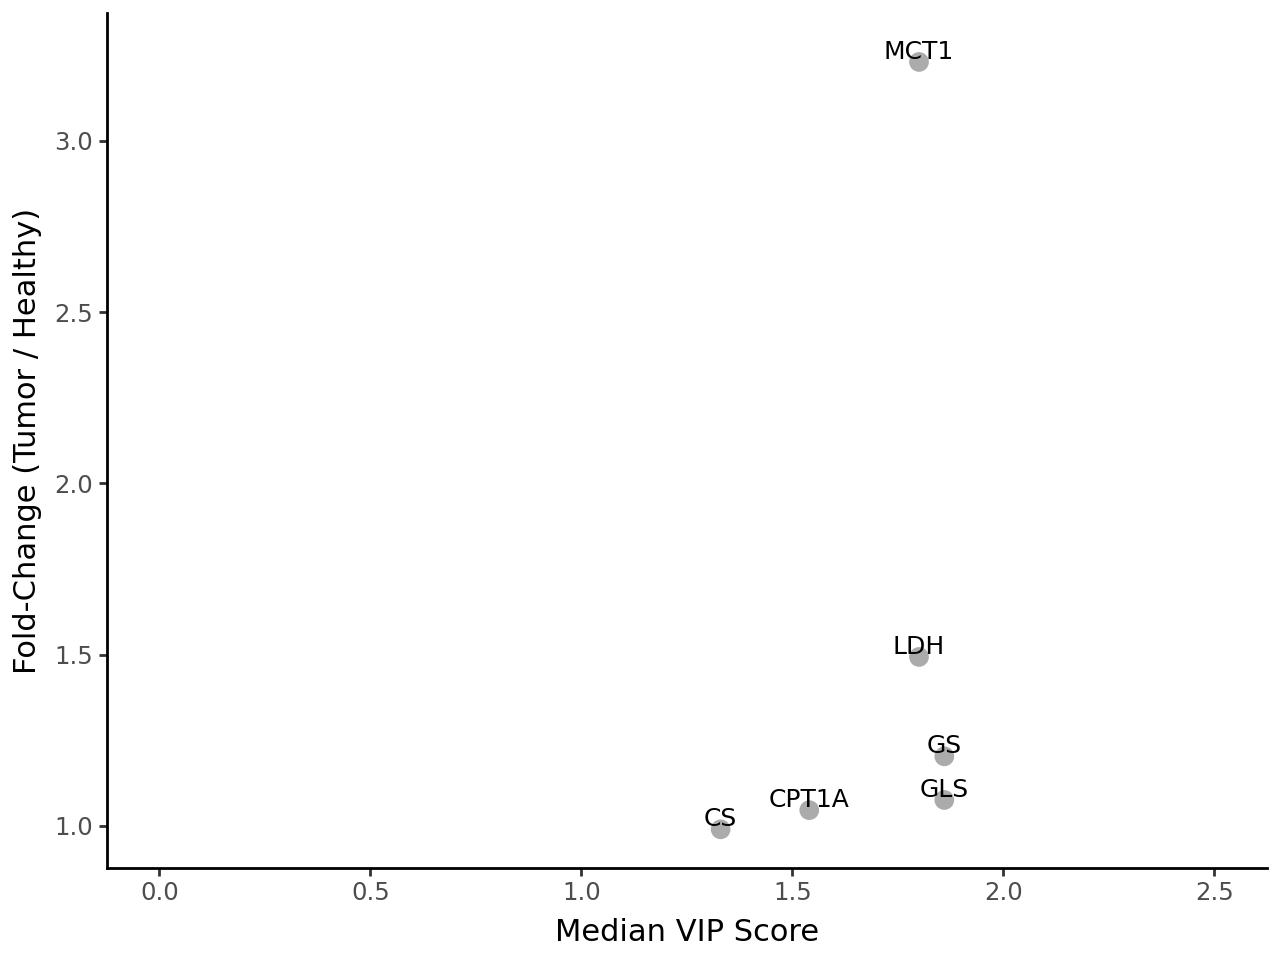

In [29]:
# Scatter: median VIP score per metabolite vs FC of corresponding regulators
regulator_metabolite = {
    'LDH': 'Lactate', 'MCT1': 'Lactate',
    'GS': 'Glutamate', 'GLS': 'Glutamate',
    'CPT1A': 'Palmitoleate', 'CS': 'Aspartate'
}

vip_median = vip_df.median(axis=1)

scatter_df = pd.DataFrame([
    {'Regulator': reg, 'VIP_Score': vip_median[met],
     'FC': fc.loc[fc['Marker'] == reg, 'FC'].values[0]}
    for reg, met in regulator_metabolite.items()
])

p = (ggplot(scatter_df, aes(x='VIP_Score', y='FC', label='Regulator'))
     + geom_point(size=3, color='#acabab')
     + geom_text(nudge_y=0.03, size=9)
     + xlim(0, 2.5)
     + labs(x='Median VIP Score', y='Fold-Change (Tumor / Healthy)')
     + theme_classic())
ggsave(p, filename=f'../../figures/fig3/metabolomics_scatter.pdf', width=4, height=4)
print(p)